# SAE architectures & JumpReLU — the activation GemmaScope uses

*Part 2 of 4.* In [Part 1](01_saes_from_scratch.ipynb) we built a plain **ReLU SAE**
with an **L1** sparsity penalty and watched it recover features from superposition. We also
flagged a tension: we *want* to control **L0** (the count of active latents) but we can only
*train* against **L1** (the sum of magnitudes). That mismatch has a concrete, damaging
side-effect — **shrinkage** — and fixing it is what the modern SAE zoo (TopK, Gated,
**JumpReLU**) is all about.

This notebook:

1. demonstrates the L1 **shrinkage / feature-suppression** problem quantitatively,
2. surveys the fixes (TopK, Gated, JumpReLU),
3. shows **why a threshold** is the right tool — encoder scores are true signal *plus
   positive leakage* from non-orthogonal features; hard vs soft thresholding,
4. implements **JumpReLU** properly — including its straight-through-estimator gradients, by
   hand — and shows it removes shrinkage,
5. and connects to **GemmaScope**, whose exact forward pass we'll load in Part 3.

Runs on CPU in well under a minute.


## 1. The problem with L1: shrinkage

Look again at the ReLU SAE loss:

$$\mathcal{L} = \lVert \mathbf{x}-\hat{\mathbf{x}}\rVert_2^2 + \lambda\lVert\mathbf{f}\rVert_1 .$$

The L1 term penalises **every unit of activation**, including the activations we *want* to
keep. So for a latent that genuinely should fire, the optimiser faces a tug of war: turning it
up improves reconstruction but costs $\lambda$ per unit. The compromise is to make the
activation **smaller than it should be**. This is *activation shrinkage* (a.k.a. feature
suppression): the SAE systematically **under-estimates** how strongly each feature is present.
The direction (which feature) is right; the magnitude is biased low.

We can measure it exactly on the Part-1 toy, because there we *know* the true magnitude of
each active feature. Plot the SAE's recovered activation against the true magnitude, for a
well-matched latent, and read off the slope: **slope 1 = unbiased, slope < 1 = shrinkage.**


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

# --- same known-dictionary generator as Part 1 ---
d, n_true, d_sae = 16, 32, 64
D_true = F.normalize(torch.randn(n_true, d), dim=-1)
p_active = 3.0 / n_true
def gen(b):
    m = (torch.rand(b, n_true) < p_active).float()
    mags = (0.5 + torch.rand(b, n_true)) * m
    return mags @ D_true, mags

class ReLUSAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.b_dec = nn.Parameter(torch.zeros(d))
        self.W_enc = nn.Parameter(torch.randn(d, d_sae) / np.sqrt(d))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(F.normalize(torch.randn(d_sae, d), dim=-1))
    @torch.no_grad()
    def nd(self): self.W_dec.data = F.normalize(self.W_dec.data, dim=-1)
    def forward(self, x):
        f = F.relu((x - self.b_dec) @ self.W_enc + self.b_enc)
        return f @ self.W_dec + self.b_dec, f

def train_relu(sae, l1, steps=2500, lr=4e-3):
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    for _ in range(steps):
        x, _ = gen(4096); xh, f = sae(x)
        (((xh - x) ** 2).sum(-1).mean() + l1 * f.abs().sum(-1).mean()).backward()
        opt.step(); opt.zero_grad(); sae.nd()
    return sae

def shrinkage_pairs(sae):
    # (true magnitude, sae activation) over all matched, active feature/latent pairs
    x, mags = gen(16384)
    with torch.no_grad(): a = sae(x)[1]          # (recon, f) -> f
    cos = F.normalize(D_true, dim=-1) @ F.normalize(sae.W_dec, dim=-1).T
    bv, bi = cos.max(1); tm, sm = [], []
    for j in range(n_true):
        if bv[j] < 0.9: continue
        on = mags[:, j] > 0
        tm.append(mags[on, j]); sm.append(a[on, bi[j].item()])
    tm, sm = torch.cat(tm), torch.cat(sm)
    A = torch.stack([tm, torch.ones_like(tm)], 1)
    slope, intcpt = torch.linalg.lstsq(A, sm).solution.tolist()
    l0 = (a > 0).float().sum(-1).mean().item()
    return tm, sm, slope, intcpt, l0

relu_sae = train_relu(ReLUSAE(), l1=0.8)
tm_r, sm_r, slope_r, int_r, l0_r = shrinkage_pairs(relu_sae)
print(f"ReLU SAE:  L0={l0_r:.1f}   recovered ≈ {slope_r:.2f} × true magnitude  (slope<1 ⇒ shrinkage)")


ReLU SAE:  L0=5.3   recovered ≈ 0.64 × true magnitude  (slope<1 ⇒ shrinkage)


The ReLU SAE recovers only **~65%** of each feature's true magnitude — a large, systematic
bias. In a real model this means downstream analyses that use SAE activation *values* (steering
strengths, attributions) are all mis-scaled.

### Why not just... not penalise magnitude?

Because the penalty is doing two jobs at once: (a) deciding *which* latents are on (the part we
want) and (b) squashing *how big* the on-latents are (the part we don't). We want to keep (a)
and drop (b). Every architecture below is a different way to separate those two jobs.


## 2. The fixes, at a glance

| Architecture | Activation / mechanism | Sparsity control | Idea |
|---|---|---|---|
| **ReLU + L1** (baseline) | $\operatorname{ReLU}(W_{\text{enc}}x+b)$ | L1 penalty $\lambda\lVert f\rVert_1$ | simple, but L1 causes shrinkage; L0 only controlled indirectly via $\lambda$ |
| **TopK** | keep the $k$ largest pre-activations, zero the rest | **exact**: L0 $=k$ by construction | no magnitude penalty ⇒ no shrinkage; but $k$ is *fixed* per token (can't spend fewer/more) |
| **Gated** | separate **gate** (which latents fire) from **magnitude** (how much) — two encoder paths | L1 on the gate path only | decouples the two jobs explicitly; needs an auxiliary loss; trains well |
| **JumpReLU** | $\operatorname{JumpReLU}_\theta(z)=z\cdot\mathbb{1}[z>\theta]$, learned per-latent threshold $\theta$ | **L0 penalty directly** $\lambda\lVert f\rVert_0$ | a ReLU with a learned "on" threshold; penalise the *count*, not the magnitude |

**TopK**'s catch (beyond the table): every token uses *exactly* $k$ latents — one that needs only
2 features still burns $k$, and one that needs $2k$ can't have them.

**Gated** and **JumpReLU** both let L0 vary per token while avoiding shrinkage. They're closely
related: with a bit of weight-tying a Gated SAE *is* a JumpReLU SAE. GemmaScope chose
**JumpReLU**, so that's what we build.


## 3. Why a threshold? Leakage is often *positive*

In Part 1 the ReLU cleaned up interference — but only because those toys embedded features
*antipodally*, so the interference landed on the negative side. Real overcomplete dictionaries
aren't that kind. Think of the encoder as a bank of **matched filters**: latent $i$ scores the
activation by dot product with its feature direction,

$$
a_i \;=\; d_i^\top x
\;=\; s_i \;+\; \underbrace{\sum_{j\neq i} \big(d_i^\top d_j\big)\, s_j}_{\text{leakage}}\,,
$$

true signal plus leakage from every correlated feature. An overcomplete dictionary *cannot* be
orthogonal, so some $d_i^\top d_j \neq 0$ — and their signs are whatever geometry dictates.

Concretely: three unit-norm features in 2-D, with only feature 1 active,

$$
D = \begin{pmatrix} 1 & 0.6 & 0.6 \\ 0 & 0.8 & -0.8 \end{pmatrix},
\qquad
x = d_1 = \begin{pmatrix}1\\0\end{pmatrix}
\;\Rightarrow\;
a = D^\top x = \begin{pmatrix}1\\0.6\\0.6\end{pmatrix}.
$$

The $0.6$s are pure leakage — and **positive**, so ReLU keeps them: it is the maximally
permissive detector, "activate on *any* positive correlation". What separates signal from
leakage here is not sign but **size**. A threshold $\theta = 0.7$ recovers $z = (1,0,0)$
exactly, and works whenever sparsity keeps the accumulated leakage below the true activations:

$$
\max_{\text{inactive } i} a_i \;<\; \theta \;<\; \min_{\text{active } i} a_i .
$$

But *how* you threshold matters:

| score $a$ | ReLU | $\operatorname{ReLU}(a-0.7)$ — **soft** | $\operatorname{JumpReLU}_{0.7}$ — **hard** |
|---:|---:|---:|---:|
| $0.6$ (leakage) | $0.6$ | $0$ | $0$ |
| $1.2$ (signal) | $1.2$ | $\mathbf{0.5}$ | $\mathbf{1.2}$ |

Folding the threshold into the encoder bias, $\operatorname{ReLU}(a-\theta)$, is **soft
thresholding**: it rejects the leakage, but it also subtracts $\theta$ from every genuine
activation — that is exactly §1's shrinkage, rebuilt by hand. **JumpReLU is hard
thresholding**: below $\theta$, off; above $\theta$, *full* magnitude. This is textbook sparse
denoising — discard small coefficients as leakage, keep large ones untouched — except the
basis is learned and overcomplete, with one learned threshold per latent.


In [ ]:
import numpy as np, matplotlib.pyplot as plt

# 3 unit-norm feature directions in 2-D — overcomplete, so they can't be orthogonal
D = np.array([[1.0, 0.6,  0.6],
              [0.0, 0.8, -0.8]])
x = D @ np.array([1.0, 0.0, 0.0])   # only feature 1 is active
a = D.T @ x                          # matched-filter scores  a_i = d_i . x
theta = 0.7
print("scores     a =", a, "  <- the 0.6s are pure (positive!) leakage")
print("ReLU         :", np.maximum(a, 0))
print("soft, a-theta:", np.maximum(a - theta, 0))
print("hard/JumpReLU:", a * (a > theta))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9))

# left: the three gates as transfer curves
u = np.linspace(-0.5, 1.5, 401)
ax = axes[0]
ax.plot(u, np.maximum(u, 0), color="0.55", lw=2, label="ReLU")
ax.plot(u, np.maximum(u - theta, 0), color="#d1495b", lw=2, label=r"ReLU$(a-\theta)$ — soft")
ax.plot([-0.5, theta], [0, 0], color="#f08c00", lw=2.6)
ax.plot([theta, 1.5], [theta, 1.5], color="#f08c00", lw=2.6, label=r"JumpReLU$_\theta$ — hard")
ax.scatter([theta], [theta], s=30, color="#f08c00", zorder=3)
ax.scatter([theta], [0], s=30, facecolor="white", edgecolor="#f08c00", zorder=3)
ax.axvline(theta, color="0.8", lw=0.8, ls=":")
ax.annotate("", xy=(1.2, 1.2), xytext=(1.2, 0.5),
            arrowprops=dict(arrowstyle="<->", color="0.35", lw=1.2))
ax.text(1.24, 0.83, "shrinkage", fontsize=9, color="0.35")
ax.set_xlabel("pre-activation $a$"); ax.set_ylabel("output")
ax.set_title("soft vs hard thresholding", fontsize=11)
ax.legend(fontsize=9, loc="upper left"); ax.grid(alpha=0.25, ls=":")

# right: the worked example — what the threshold must separate
ax = axes[1]
ax.bar(range(3), a, width=0.55, color=["#4c8dd6", "0.65", "0.65"])
ax.axhline(theta, color="#f08c00", lw=2, ls="--")
ax.text(2.42, theta + 0.04, r"$\theta = 0.7$", color="#f08c00", ha="right", fontsize=10)
ax.set_xticks(range(3), ["$a_1$ (signal)", "$a_2$ (leakage)", "$a_3$ (leakage)"], fontsize=9)
ax.set_ylim(0, 1.25)
ax.set_title("encoder scores: only feature 1 is truly on", fontsize=11)
ax.grid(alpha=0.25, ls=":", axis="y")

fig.tight_layout(); plt.show()

## 4. JumpReLU in depth

The JumpReLU activation is a ReLU with a learned **threshold** $\theta_i$ per latent:

$$\operatorname{JumpReLU}_\theta(z) \;=\; z\cdot H(z-\theta),\qquad H(u)=\mathbb{1}[u>0]\ \text{(Heaviside step)}.$$

Below the threshold the latent is exactly off; above it, the latent passes through **at full
magnitude** (no shrinkage). Sparsity is now controlled by penalising the **L0 count** directly:

$$\mathcal{L}(\mathbf{x}) \;=\; \underbrace{\lVert\mathbf{x}-\hat{\mathbf{x}}\rVert_2^2}_{\text{reconstruct}} \;+\;
  \underbrace{\lambda\,\lVert\mathbf{f}\rVert_0}_{\text{sparsity}},\qquad
  \lVert\mathbf{f}\rVert_0=\sum_i H(z_i-\theta_i).$$

This is *exactly* the thing we said we wanted in Part 1. So what was stopping us? **The
gradients are dead.** Both $H(z-\theta)$ (a step) and $\lVert f\rVert_0$ (a count) are
piecewise-constant in $\theta$, so $\partial/\partial\theta = 0$ almost everywhere — the
threshold would never move.

### Straight-through estimators (STE)

The trick: in the **backward** pass, replace the useless zero-derivative with a **pseudo-derivative**
that's a narrow bump around the discontinuity. Concretely, DeepMind use a **rectangle kernel**
$K(u)=\mathbb{1}[|u|<\tfrac12]$ of bandwidth $\varepsilon$, and define:

$$
\frac{\partial}{\partial\theta}H(z-\theta) := -\frac{1}{\varepsilon}K\!\Big(\frac{z-\theta}{\varepsilon}\Big),
\qquad
\frac{\partial}{\partial\theta}\operatorname{JumpReLU}_\theta(z) := -\frac{\theta}{\varepsilon}K\!\Big(\frac{z-\theta}{\varepsilon}\Big).
$$

Intuition: nudging $\theta$ only matters for inputs $z$ sitting *right at* the threshold (within
$\varepsilon$). For those, lowering $\theta$ turns the latent on (gaining a count of 1, or a
magnitude of $\theta$); the kernel concentrates that effect in a narrow window of width
$\varepsilon$ around $\theta$. For the *input* $z$ we
keep the honest derivatives ($\partial H/\partial z:=0$, $\partial\operatorname{JumpReLU}/\partial z:=\mathbb{1}[z>\theta]$)
so that $\theta$ is the *only* parameter that implements thresholding.

We implement both as custom `torch.autograd.Function`s with different forward/backward behaviour.


In [2]:
def rectangle(x, width=1.0):
    return (x.abs() < width / 2).float()

class Heaviside(torch.autograd.Function):
    # forward: 1[z > θ];   backward: dH/dz := 0,  dH/dθ := -(1/ε)·K((z-θ)/ε)
    @staticmethod
    def forward(ctx, z, theta, eps):
        ctx.save_for_backward(z, theta); ctx.eps = eps
        return (z > theta).float()
    @staticmethod
    def backward(ctx, grad_out):
        z, theta = ctx.saved_tensors; eps = ctx.eps
        grad_theta = -(1.0 / eps) * rectangle((z - theta) / eps) * grad_out
        return 0.0 * grad_out, grad_theta, None

class JumpReLU(torch.autograd.Function):
    # forward: z·1[z > θ];   backward: dJ/dz := 1[z>θ],  dJ/dθ := -(θ/ε)·K((z-θ)/ε)
    @staticmethod
    def forward(ctx, z, theta, eps):
        ctx.save_for_backward(z, theta); ctx.eps = eps
        return z * (z > theta).float()
    @staticmethod
    def backward(ctx, grad_out):
        z, theta = ctx.saved_tensors; eps = ctx.eps
        grad_z = (z > theta).float() * grad_out
        grad_theta = -(theta / eps) * rectangle((z - theta) / eps) * grad_out
        return grad_z, grad_theta, None

# --- unit tests (from the DeepMind/ARENA conventions) ---
z = torch.tensor([[1.0, 1.4, 1.6, 2.0]], requires_grad=True)
theta = torch.tensor([1.5, 1.5, 1.5, 1.5], requires_grad=True)
out = JumpReLU.apply(z, theta, 0.5); out.backward(torch.ones_like(out))
torch.testing.assert_close(out, torch.tensor([[0.0, 0.0, 1.6, 2.0]]))            # z·1[z>θ]
torch.testing.assert_close(theta.grad, torch.tensor([0.0, -3.0, -3.0, 0.0]))     # -θ/ε·K
torch.testing.assert_close(z.grad, torch.tensor([[0.0, 0.0, 1.0, 1.0]]))         # 1[z>θ]
print("JumpReLU forward & straight-through gradients: tests passed ✓")


JumpReLU forward & straight-through gradients: tests passed ✓


### A JumpReLU SAE

Now assemble the SAE. Two implementation details that matter (both from the GemmaScope /
DeepMind appendix):

- Parameterise the threshold as $\theta=\exp(\log\theta)$ so it stays positive and the learnable
  parameter is unconstrained.
- Feed $\operatorname{ReLU}(\text{pre})$ (not the raw pre-activation) into the JumpReLU/Heaviside, so negative
  pre-activations can't leak gradient into $\theta$ in edge cases.


In [3]:
class JumpReLUSAE(nn.Module):
    def __init__(self, eps=0.02, theta0=0.05):
        super().__init__(); self.eps = eps
        self.b_dec = nn.Parameter(torch.zeros(d))
        self.W_enc = nn.Parameter(torch.randn(d, d_sae) / np.sqrt(d))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(F.normalize(torch.randn(d_sae, d), dim=-1))
        self.log_theta = nn.Parameter(torch.full((d_sae,), float(np.log(theta0))))
    @property
    def theta(self): return self.log_theta.exp()
    @torch.no_grad()
    def nd(self): self.W_dec.data = F.normalize(self.W_dec.data, dim=-1)
    def forward(self, x):
        pre = (x - self.b_dec) @ self.W_enc + self.b_enc           # pre-activations
        z = F.relu(pre)                                            # z = ReLU(pre-acts) — the value we threshold
        acts = JumpReLU.apply(z, self.theta, self.eps)             # pass z only where z > θ (at full magnitude)
        return acts @ self.W_dec + self.b_dec, acts, z

def train_jump(sae, lam, steps=2500, lr=4e-3):
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    for _ in range(steps):
        x, _ = gen(4096); xh, acts, z = sae(x)
        l0_pen = Heaviside.apply(z, sae.theta, sae.eps).sum(-1).mean()   # count of active latents — Heaviside (not z>0) so the STE gradient can still reach θ
        (((xh - x) ** 2).sum(-1).mean() + lam * l0_pen).backward()
        opt.step(); opt.zero_grad(); sae.nd()
    return sae

jump_sae = train_jump(JumpReLUSAE(), lam=0.15)

# reuse the shrinkage probe (works for any SAE returning (recon, acts, ...))
def shrink_pairs(sae):
    x, mags = gen(16384)
    with torch.no_grad(): acts = sae(x)[1]
    cos = F.normalize(D_true, dim=-1) @ F.normalize(sae.W_dec, dim=-1).T
    bv, bi = cos.max(1); tm, sm = [], []
    for j in range(n_true):
        if bv[j] < 0.9: continue
        on = mags[:, j] > 0
        tm.append(mags[on, j]); sm.append(acts[on, bi[j].item()])
    tm, sm = torch.cat(tm), torch.cat(sm)
    A = torch.stack([tm, torch.ones_like(tm)], 1)
    slope, intcpt = torch.linalg.lstsq(A, sm).solution.tolist()
    l0 = (acts > 0).float().sum(-1).mean().item()
    return tm, sm, slope, l0

tm_j, sm_j, slope_j, l0_j = shrink_pairs(jump_sae)
print(f"JumpReLU SAE:  L0={l0_j:.1f}   recovered ≈ {slope_j:.2f} × true magnitude  (slope≈1 ⇒ no shrinkage)")


JumpReLU SAE:  L0=2.9   recovered ≈ 0.91 × true magnitude  (slope≈1 ⇒ no shrinkage)


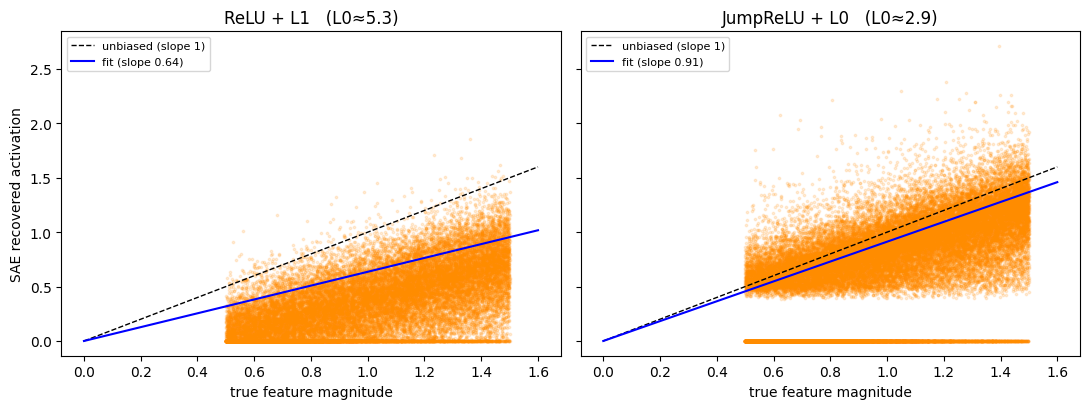

In [4]:
# side-by-side: recovered activation vs true magnitude
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for a_, tm, sm, slope, l0, name in [
    (ax[0], tm_r, sm_r, slope_r, l0_r, "ReLU + L1"),
    (ax[1], tm_j, sm_j, slope_j, l0_j, "JumpReLU + L0"),
]:
    a_.scatter(tm, sm, s=3, alpha=0.15, color="darkorange")
    xs = torch.linspace(0, 1.6, 20)
    a_.plot(xs, xs, "k--", lw=1, label="unbiased (slope 1)")
    a_.plot(xs, slope * xs, "b-", lw=1.5, label=f"fit (slope {slope:.2f})")
    a_.set_title(f"{name}   (L0≈{l0:.1f})"); a_.set_xlabel("true feature magnitude")
    a_.legend(loc="upper left", fontsize=8)
ax[0].set_ylabel("SAE recovered activation")
plt.tight_layout(); plt.show()


Same reconstruction task — and JumpReLU is if anything *sparser* (L0 2.9 vs 5.3) — yet the
**ReLU cloud sits well below the diagonal (slope ≈ 0.65)** while the **JumpReLU cloud hugs it
(slope ≈ 0.9–1.0)**. JumpReLU removed the shrinkage bias because it never penalises magnitude,
only the *count* of active latents. (The slight negative intercept is the threshold zeroing weak
activations — pinning the low end at zero, not shrinking the survivors.)


## 5. The frontier: same reconstruction at lower L0

The other benefit is a better **L0-vs-reconstruction trade-off**. Sweep the sparsity coefficient
for each architecture and plot the frontier — down-and-left is better (fewer active latents for
the same error).


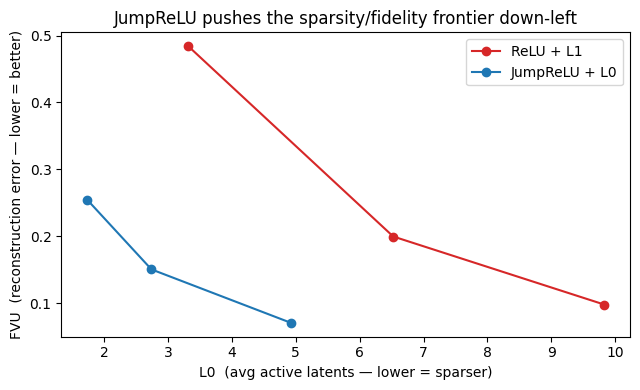

In [5]:
def eval_sae(sae):
    x, _ = gen(16384)
    with torch.no_grad(): xh, acts, *_ = sae(x)
    l0 = (acts > 0).float().sum(-1).mean().item()
    fvu = (((xh - x) ** 2).sum() / ((x - x.mean(0)) ** 2).sum()).item()
    return l0, fvu

relu_pts = [eval_sae(train_relu(ReLUSAE(), l1, steps=1500)) for l1 in [0.3, 0.6, 1.2]]
jump_pts = [eval_sae(train_jump(JumpReLUSAE(), lam, steps=1500)) for lam in [0.08, 0.2, 0.5]]

plt.figure(figsize=(6.5, 4))
for pts, name, c in [(relu_pts, "ReLU + L1", "tab:red"), (jump_pts, "JumpReLU + L0", "tab:blue")]:
    pts = sorted(pts); xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
    plt.plot(xs, ys, "o-", color=c, label=name)
plt.xlabel("L0  (avg active latents — lower = sparser)")
plt.ylabel("FVU  (reconstruction error — lower = better)")
plt.title("JumpReLU pushes the sparsity/fidelity frontier down-left")
plt.legend(); plt.tight_layout(); plt.show()


## 6. GemmaScope: JumpReLU at scale

[**GemmaScope**](https://deepmind.google/discover/blog/gemma-scope-helping-the-safety-community-shed-light-on-the-inner-workings-of-language-models/)
is DeepMind's open release of *hundreds* of JumpReLU SAEs for the Gemma models — every layer,
several widths, and the **GemmaScope-2** update covers **Gemma 3** (including the
`gemma-3-1b-pt` model we'll use). Everything in this notebook is exactly what's under the hood,
with three scaling-up details:

- **Width & L0.** Our target SAE is `resid_post`, layer 13, **width 16384** (`16k`),
  trained to **L0 ≈ 60**. Each (layer, width) is released at several L0 points
  (`l0_small / medium / big`); Neuronpedia serves the **medium** one for our dashboard.
- **The exact forward pass.** GemmaScope's stored parameters are
  `w_enc, w_dec, b_enc, b_dec, threshold`, and the forward is precisely:

  ```python
  pre  = x @ W_enc + b_enc
  acts = relu(pre) * (pre > threshold)     # JumpReLU with a *fixed* learned threshold
  recon = acts @ W_dec + b_dec
  ```

  At *inference* the STE machinery is gone — `threshold` is just a constant vector. The STE
  only existed to *train* those thresholds. (We'll load these real weights in Part 3.)
- **Targeting a specific L0.** Rather than hunting $\lambda$, you can penalise the squared
  distance to a target, $\lambda\big(\lVert f\rVert_0 / L_0^{\text{target}} - 1\big)^2$, which
  lets you dial in "L0 ≈ 60" directly. GemmaScope-style training also **normalises activations**
  (so $\mathbb{E}\lVert x\rVert=\sqrt{d_{\text{model}}}$), **warms up** the sparsity coefficient,
  and **resamples dead latents** — all of which we'll do for real in Part 4.

A caveat worth internalising: JumpReLU SAEs are **harder to train** than the maths suggests —
several groups struggled to reproduce DeepMind's results, largely because of the threshold
gradient. Our from-scratch run in Part 4 will hit the same issues (dead latents, L0 that
overshoots) and show the fixes.


## Recap & what's next

- **L1 causes shrinkage**: the penalty on magnitude biases recovered activations low
  (slope ≈ 0.65 on our toy).
- **Why a threshold**: overcomplete dictionaries *leak* — an encoder score is true signal
  plus interference from correlated features, and the leakage is often **positive**, so
  ReLU keeps it. Soft thresholding (fold $\theta$ into the bias) rejects leakage but
  shrinks; **hard thresholding (JumpReLU) rejects leakage at full magnitude**.
- **TopK / Gated / JumpReLU** separate "which latents fire" from "how big they are".
  **JumpReLU** = ReLU with a learned per-latent threshold + a direct **L0** penalty, trained via
  **straight-through estimators** with a rectangle kernel.
- JumpReLU removes shrinkage (slope ≈ 1) and improves the L0/fidelity frontier — which is why
  **GemmaScope uses it**.

**Next → Part 3: Reconstructing the Neuronpedia dashboard.** We load the *real* GemmaScope-2
SAE for Gemma 3, run Gemma 3 1B on text, and rebuild every panel of the
[latent-7447 dashboard](https://www.neuronpedia.org/gemma-3-1b/13-gemmascope-2-res-16k/7447)
— top logits, activation density, max-activating examples, cosine neighbours — from scratch.
